# Algoritmos de Optimización

## ¿Qué es un algoritmo de optimización?

Un algoritmo de optimización busca encontrar el **mínimo** (o m\u00e1ximo) de una función objetivo $f(x)$. Formalmente:

$$
x^* = \arg\min_{x} f(x)
$$

Donde $x^*$ es el punto óptimo que minimiza $f$. La optimización es el corazón del **Machine Learning**: entrenar un modelo equivale a minimizar una función de costo.

### Clasificación

| Tipo | Usa gradiente | Ejemplo |
|---|---|---|
| **Basados en gradiente** | Sí | Gradient Descent, Newton, SGD, Adam |
| **Metaheurísticos** | No | Simulated Annealing, PSO, Genético |

Los métodos basados en gradiente usan la derivada $\nabla f(x)$ para saber hacia dónde moverse. Los metaheurísticos exploran el espacio de búsqueda sin necesitar derivadas, lo que los hace útiles para funciones no diferenciables o con muchos mínimos locales.

### Función de ejemplo

A lo largo de este notebook usaremos varias funciones, pero nuestra función principal ser\u00e1:

$$
f(x) = x^4 - 5x^2 + 4
$$

Esta función tiene **múltiples mínimos locales**, lo que la hace interesante para comparar algoritmos.

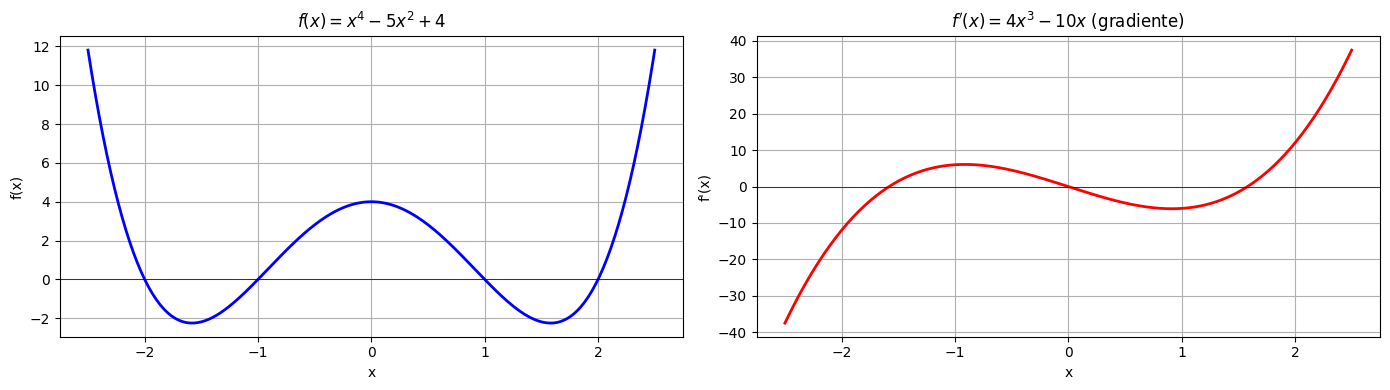

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

import warnings
warnings.filterwarnings("ignore")

# Función de ejemplo y su derivada
def f(x):
    return x**4 - 5*x**2 + 4

def df(x):
    return 4*x**3 - 10*x

def ddf(x):
    return 12*x**2 - 10

x = np.linspace(-2.5, 2.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(x, f(x), 'b-', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_title('$f(x) = x^4 - 5x^2 + 4$')
axes[0].grid(True)
axes[0].axhline(y=0, color='k', linewidth=0.5)

axes[1].plot(x, df(x), 'r-', linewidth=2)
axes[1].set_xlabel('x')
axes[1].set_ylabel("f'(x)")
axes[1].set_title("$f'(x) = 4x^3 - 10x$ (gradiente)")
axes[1].grid(True)
axes[1].axhline(y=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

## Descenso del Gradiente (*Gradient Descent*)

### ¿Cómo funciona?

El descenso del gradiente es el algoritmo de optimización más fundamental. La idea es simple: **moverse en la dirección opuesta al gradiente** (la pendiente), porque esa es la dirección de mayor descenso.

La regla de actualización es:

$$
x_{t+1} = x_t - \alpha \cdot \nabla f(x_t)
$$

Donde:
- $x_t$: posición actual
- $\alpha$: **tasa de aprendizaje** (*learning rate*) - qué tan grande es cada paso
- $\nabla f(x_t)$: gradiente (derivada) de $f$ evaluada en $x_t$

**Pseudocódigo:**

```
función gradient_descent(f', x_0, α, iteraciones):
    x = x_0
    para t desde 1 hasta iteraciones:
        x = x - α · f'(x)
    retornar x
```

Es como una pelota rodando cuesta abajo: se mueve en la dirección de mayor pendiente hasta llegar a un valle.

**Parámetro clave - Tasa de aprendizaje $\alpha$:**
- Muy pequeña: convergencia lenta
- Muy grande: puede oscilar o divergir
- Correcta: convergencia rápida y estable

### Convergencia

Para una función convexa con gradiente Lipschitz continuo (constante $L$), si elegimos $\alpha \leq \frac{1}{L}$:

$$
f(x_t) - f(x^*) \leq \frac{\|x_0 - x^*\|^2}{2\alpha t}
$$

Esto significa que el error decrece como $O(1/t)$, es decir, se necesitan $O(1/\epsilon)$ iteraciones para alcanzar una precisión $\epsilon$.

La tasa de aprendizaje controla un *trade-off*: pasos grandes avanzan rápido pero pueden sobrepasar el mínimo; pasos pequeños son seguros pero lentos.

### Ejemplo paso a paso

Minimicemos $f(x) = x^4 - 5x^2 + 4$ desde $x_0 = 2.0$ con $\alpha = 0.05$:

| Iteración | $x_t$ | $f(x_t)$ | $f'(x_t)$ | $x_{t+1} = x_t - 0.05 \cdot f'(x_t)$ |
|-----------|--------|-----------|------------|---------------------------------------|
| 0 | 2.000 | 0.000 | 12.000 | 1.400 |
| 1 | 1.400 | -3.198 | 0.976 | 1.351 |
| 2 | 1.351 | -3.249 | 0.337 | 1.334 |
| 3 | 1.334 | -3.253 | 0.111 | 1.329 |
| ... | ... | ... | ... | ... |
| $\to$ | **1.581** | **-2.250** | **≈ 0** | convergencia |

El mínimo local está en $x^* = \sqrt{5/2} \approx 1.581$.

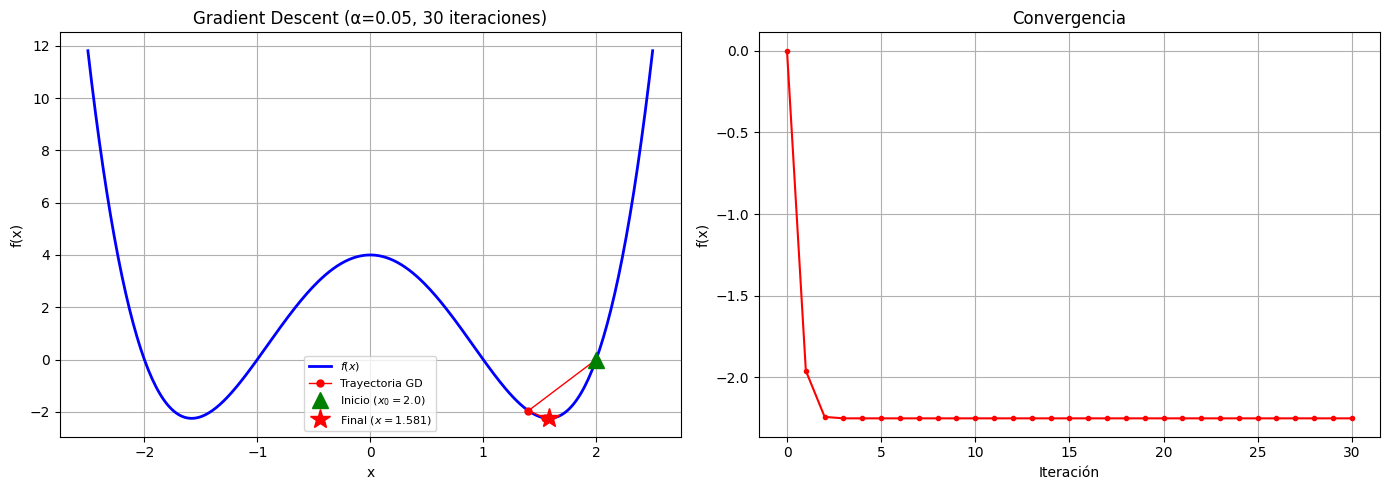

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x): return x**4 - 5*x**2 + 4
def df(x): return 4*x**3 - 10*x

# Gradient Descent
x0, lr, n_iter = 2.0, 0.05, 30
path = [x0]
x = x0
for _ in range(n_iter):
    x = x - lr * df(x)
    path.append(x)

path = np.array(path)
x_range = np.linspace(-2.5, 2.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trayectoria sobre la función
axes[0].plot(x_range, f(x_range), 'b-', linewidth=2, label='$f(x)$')
axes[0].plot(path, f(path), 'ro-', markersize=5, linewidth=1, label='Trayectoria GD')
axes[0].plot(path[0], f(path[0]), 'g^', markersize=12, label=f'Inicio ($x_0={x0}$)')
axes[0].plot(path[-1], f(path[-1]), 'r*', markersize=15, label=f'Final ($x={path[-1]:.3f}$)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_title(f'Gradient Descent (α={lr}, {n_iter} iteraciones)')
axes[0].legend(fontsize=8)
axes[0].grid(True)

# Convergencia
axes[1].plot(range(len(path)), f(path), 'r-o', markersize=3)
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Convergencia')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Animación interactiva

La animación muestra cómo el punto se mueve paso a paso hacia el mínimo, siguiendo la dirección opuesta al gradiente.

In [3]:
def animate_gradient_descent(f, df, x0, lr, n_iter, x_range=(-2.5, 2.5), title='Gradient Descent'):
    """Animación interactiva del Gradient Descent."""
    path = [x0]
    x = x0
    for _ in range(n_iter):
        x = x - lr * df(x)
        path.append(x)
    path = np.array(path)

    xs = np.linspace(x_range[0], x_range[1], 300)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(xs, f(xs), 'b-', linewidth=2, label='$f(x)$')
    point, = ax.plot([], [], 'ro', markersize=10, zorder=5)
    trail, = ax.plot([], [], 'r--', linewidth=1, alpha=0.5)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

    status = ax.text(0.5, 1.06, '', transform=ax.transAxes,
                     ha='center', fontsize=11, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    def update(frame):
        point.set_data([path[frame]], [f(path[frame])])
        trail.set_data(path[:frame+1], f(path[:frame+1]))
        grad = df(path[frame])
        status.set_text(f'Iter {frame}: x={path[frame]:.4f}, f(x)={f(path[frame]):.4f}, f\'(x)={grad:.4f}')
        return [point, trail, status]

    anim = FuncAnimation(fig, update, frames=len(path), interval=200, repeat=False)
    plt.close()
    return HTML(anim.to_jshtml())

In [ ]:
def f(x): return x**4 - 5*x**2 + 4
def df(x): return 4*x**3 - 10*x

animate_gradient_descent(f, df, x0=2.0, lr=0.05, n_iter=40, title='Gradient Descent (α=0.05)')

### Efecto de la tasa de aprendizaje

Veamos cómo diferentes valores de $\alpha$ afectan la convergencia:

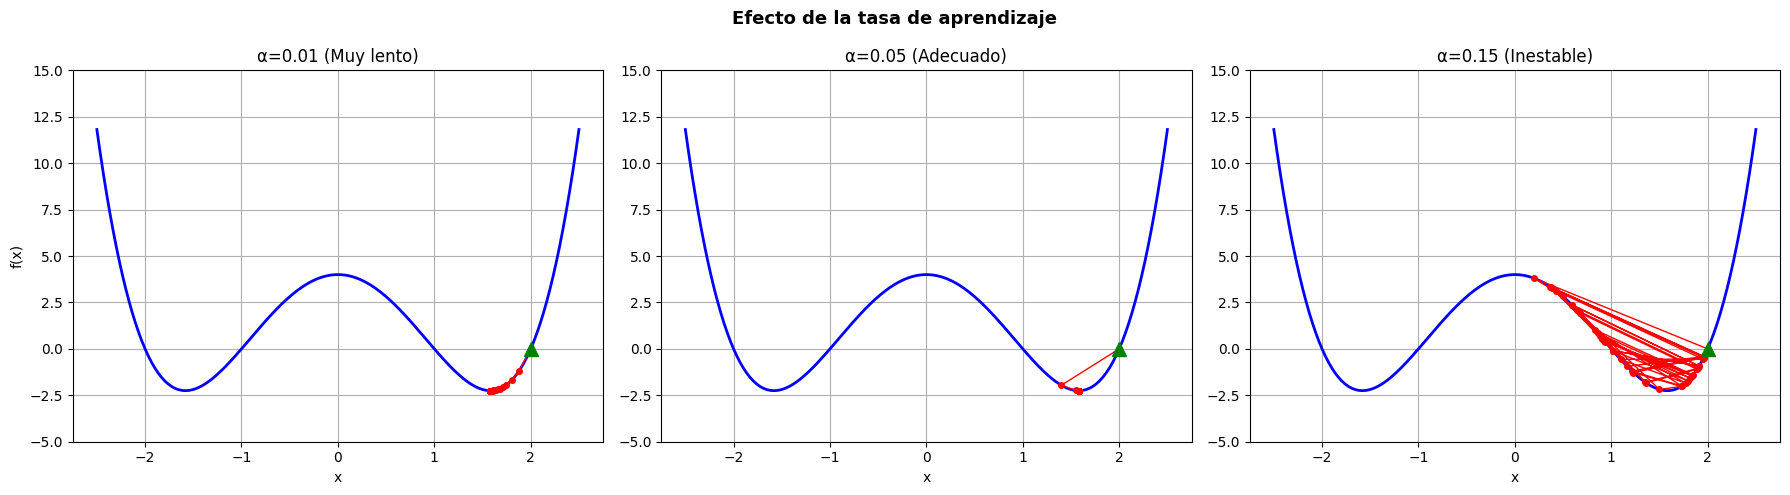

In [4]:
def f(x): return x**4 - 5*x**2 + 4
def df(x): return 4*x**3 - 10*x

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lrs = [0.01, 0.05, 0.15]
titles = ['α=0.01 (Muy lento)', 'α=0.05 (Adecuado)', 'α=0.15 (Inestable)']
x_range = np.linspace(-2.5, 2.5, 300)

for ax, lr, title in zip(axes, lrs, titles):
    x = 2.0
    path = [x]
    for _ in range(40):
        x = x - lr * df(x)
        if abs(x) > 10: break
        path.append(x)
    path = np.array(path)

    ax.plot(x_range, f(x_range), 'b-', linewidth=2)
    ax.plot(path, f(path), 'ro-', markersize=4, linewidth=1)
    ax.plot(path[0], f(path[0]), 'g^', markersize=10)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.grid(True)
    ax.set_ylim(-5, 15)

axes[0].set_ylabel('f(x)')
plt.suptitle('Efecto de la tasa de aprendizaje', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Método de Newton (*Newton's Method*)

### ¿Cómo funciona?

El método de Newton usa información de la **segunda derivada** (curvatura) para converger más rápido. En vez de solo seguir la pendiente, aproxima la función con una **parábola** en cada punto y salta directamente al mínimo de esa parábola.

La regla de actualización es:

$$
x_{t+1} = x_t - \frac{f'(x_t)}{f''(x_t)}
$$

En dimensiones múltiples:

$$
x_{t+1} = x_t - [H(x_t)]^{-1} \nabla f(x_t)
$$

Donde $H$ es la **matriz Hessiana** (matriz de segundas derivadas).

**Pseudocódigo:**

```
función newton(f', f'', x_0, iteraciones):
    x = x_0
    para t desde 1 hasta iteraciones:
        x = x - f'(x) / f''(x)
    retornar x
```

**Ventajas:** Convergencia **cuadrática** (muchísimo más rápido que GD).
**Desventajas:** Requiere calcular $f''(x)$ (costoso), puede diverger si $f''(x) \approx 0$.

### Convergencia

El método de Newton tiene convergencia **cuadrática** cerca del óptimo:

$$
|x_{t+1} - x^*| \leq C \cdot |x_t - x^*|^2
$$

Esto significa que si el error es $0.1$, en el siguiente paso será $\approx 0.01$, luego $0.0001$, etc. En la práctica, pocas iteraciones son suficientes.

**Comparación de velocidad de convergencia:**

| Método | Tasa | Iteraciones para $\epsilon = 10^{-8}$ |
|---|---|---|
| Gradient Descent | Lineal $O(1/t)$ | $\sim 10^8$ |
| **Newton** | **Cuadrática** | $\sim 27$ |

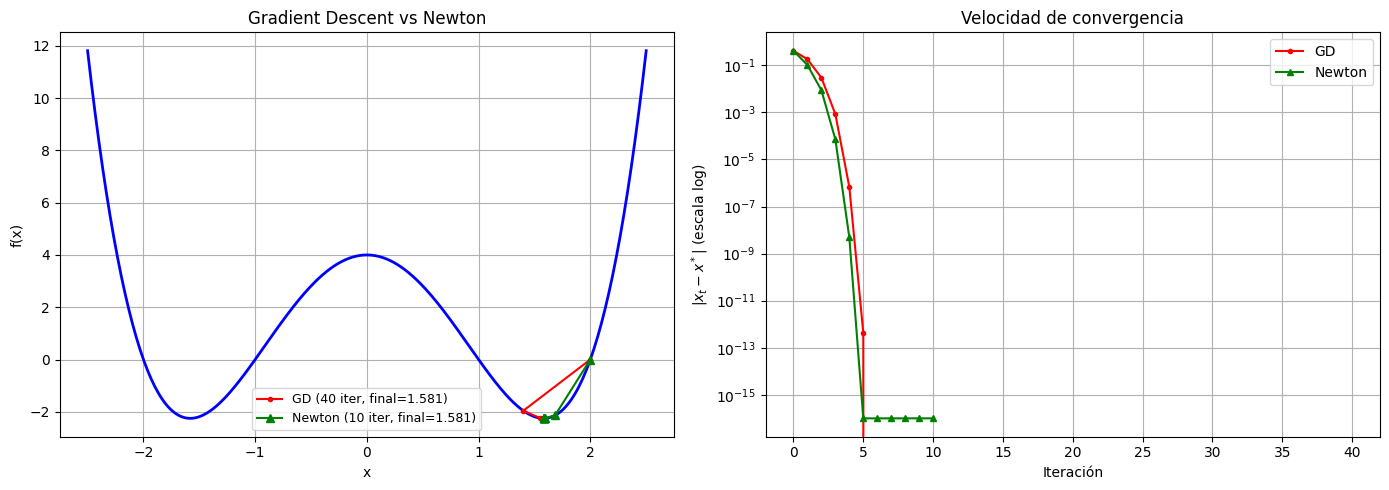

In [5]:
def f(x): return x**4 - 5*x**2 + 4
def df(x): return 4*x**3 - 10*x
def ddf(x): return 12*x**2 - 10

def newton_path(f, df, ddf, x0, n_iter):
    path = [x0]
    x = x0
    for _ in range(n_iter):
        d2 = ddf(x)
        if abs(d2) < 1e-10: break
        x = x - df(x) / d2
        path.append(x)
    return np.array(path)

# Comparar GD vs Newton
x0 = 2.0
gd_path = [x0]
x = x0
for _ in range(40):
    x = x - 0.05 * df(x)
    gd_path.append(x)
gd_path = np.array(gd_path)

nw_path = newton_path(f, df, ddf, x0, 10)
x_range = np.linspace(-2.5, 2.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trayectorias
axes[0].plot(x_range, f(x_range), 'b-', linewidth=2)
axes[0].plot(gd_path, f(gd_path), 'ro-', markersize=3, label=f'GD (40 iter, final={gd_path[-1]:.3f})')
axes[0].plot(nw_path, f(nw_path), 'g^-', markersize=6, label=f'Newton (10 iter, final={nw_path[-1]:.3f})')
axes[0].set_title('Gradient Descent vs Newton')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend(fontsize=9)
axes[0].grid(True)

# Convergencia
axes[1].semilogy(range(len(gd_path)), np.abs(gd_path - np.sqrt(2.5)), 'r-o', markersize=3, label='GD')
axes[1].semilogy(range(len(nw_path)), np.abs(nw_path - np.sqrt(2.5)) + 1e-16, 'g-^', markersize=5, label='Newton')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('$|x_t - x^*|$ (escala log)')
axes[1].set_title('Velocidad de convergencia')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Animación interactiva

In [6]:
def animate_newton(f, df, ddf, x0, n_iter, x_range=(-2.5, 2.5)):
    path = newton_path(f, df, ddf, x0, n_iter)
    xs = np.linspace(x_range[0], x_range[1], 300)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(xs, f(xs), 'b-', linewidth=2, label='$f(x)$')
    point, = ax.plot([], [], 'go', markersize=10, zorder=5)
    trail, = ax.plot([], [], 'g--', linewidth=1, alpha=0.5)
    tangent_line, = ax.plot([], [], 'm-', linewidth=1.5, alpha=0.7, label='Aprox. cuadrática')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title("Método de Newton")
    ax.legend()
    ax.grid(True)

    status = ax.text(0.5, 1.06, '', transform=ax.transAxes,
                     ha='center', fontsize=11, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    def update(frame):
        xi = path[frame]
        point.set_data([xi], [f(xi)])
        trail.set_data(path[:frame+1], f(path[:frame+1]))

        # Dibujar aproximación cuadrática local
        d1 = df(xi)
        d2 = ddf(xi)
        dx = np.linspace(xi - 1.5, xi + 1.5, 100)
        quad = f(xi) + d1 * (dx - xi) + 0.5 * d2 * (dx - xi)**2
        tangent_line.set_data(dx, quad)

        status.set_text(f"Iter {frame}: x={xi:.4f}, f(x)={f(xi):.4f}, f''(x)={d2:.2f}")
        return [point, trail, tangent_line, status]

    anim = FuncAnimation(fig, update, frames=len(path), interval=800, repeat=False)
    plt.close()
    return HTML(anim.to_jshtml())

def f(x): return x**4 - 5*x**2 + 4
def df(x): return 4*x**3 - 10*x
def ddf(x): return 12*x**2 - 10

animate_newton(f, df, ddf, x0=2.0, n_iter=10)

## Descenso del Gradiente Estocástico (*SGD*)

### ¿Cómo funciona?

En Machine Learning, la función de costo es generalmente una **suma sobre todos los datos**:

$$
f(x) = \frac{1}{N} \sum_{i=1}^{N} f_i(x)
$$

Calcular el gradiente completo ($\nabla f$) requiere procesar **todos** los $N$ datos, lo cual es costoso. El **SGD** aproxima el gradiente usando **un solo dato** (o un mini-batch) aleatorio:

$$
x_{t+1} = x_t - \alpha \cdot \nabla f_{i_t}(x_t)
$$

Donde $i_t$ es un índice aleatorio. El gradiente es **ruidoso** pero en promedio apunta en la dirección correcta:

$$
\mathbb{E}[\nabla f_{i}(x)] = \nabla f(x)
$$

**Pseudocódigo:**

```
función SGD(datos, x_0, α, epochs):
    x = x_0
    para cada epoch:
        mezclar datos aleatoriamente
        para cada dato_i en datos:
            g = gradiente de f_i en x
            x = x - α · g
    retornar x
```

Es mucho más rápido por iteración que GD, pero la trayectoria es **ruidosa**.

### Convergencia

Para funciones convexas con learning rate decreciente $\alpha_t = \frac{c}{t}$:

$$
\mathbb{E}[f(x_t) - f(x^*)] = O\left(\frac{1}{\sqrt{t}}\right)
$$

Más lento que GD ($O(1/t)$), pero cada iteraci\u00f3n es **$N$ veces más barata**.

| M\u00e9todo | Costo por iter | Iteraciones | Costo total |
|---|---|---|---|
| GD | $O(N)$ | $O(1/\epsilon)$ | $O(N/\epsilon)$ |
| SGD | $O(1)$ | $O(1/\epsilon^2)$ | $O(1/\epsilon^2)$ |

Para $N$ grande, SGD es generalmente más eficiente.

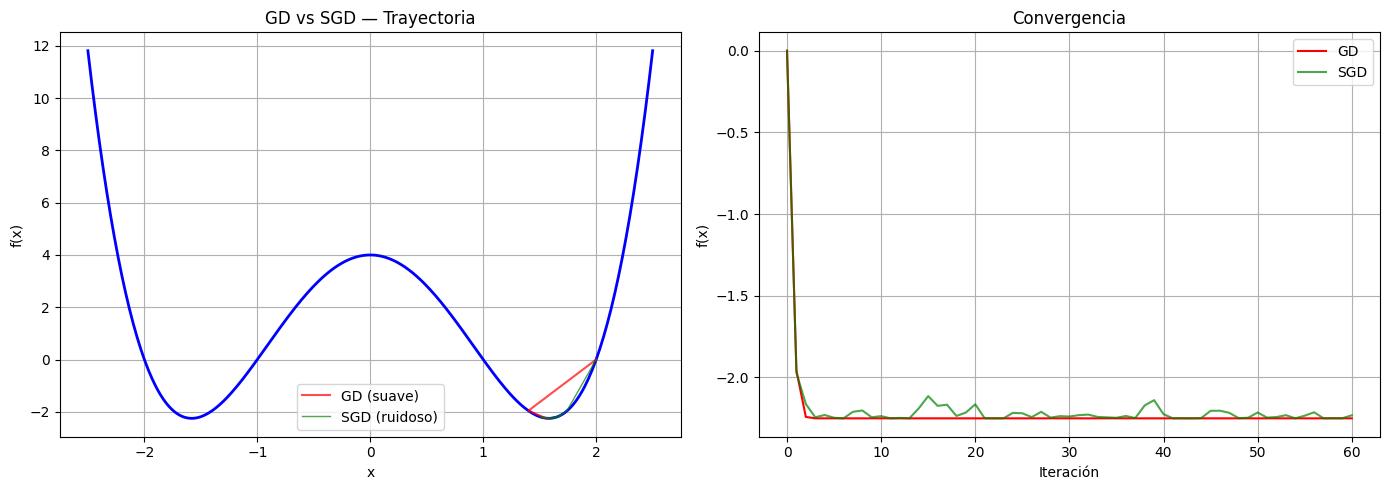

In [7]:
def f(x): return x**4 - 5*x**2 + 4
def df(x): return 4*x**3 - 10*x

def sgd_path(df, x0, lr, n_iter, noise_std=1.5):
    """SGD simulado añadiendo ruido al gradiente."""
    np.random.seed(42)
    path = [x0]
    x = x0
    for t in range(n_iter):
        noisy_grad = df(x) + np.random.normal(0, noise_std)
        x = x - lr * noisy_grad
        path.append(x)
    return np.array(path)

gd_p = [2.0]
x = 2.0
for _ in range(60):
    x = x - 0.05 * df(x)
    gd_p.append(x)
gd_p = np.array(gd_p)

sgd_p = sgd_path(df, 2.0, 0.02, 60, noise_std=2.0)
x_range = np.linspace(-2.5, 2.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_range, f(x_range), 'b-', linewidth=2)
axes[0].plot(gd_p, f(gd_p), 'r-', linewidth=1.5, alpha=0.7, label='GD (suave)')
axes[0].plot(sgd_p, f(sgd_p), 'g-', linewidth=1, alpha=0.7, label='SGD (ruidoso)')
axes[0].set_title('GD vs SGD — Trayectoria')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(f(gd_p), 'r-', label='GD')
axes[1].plot(f(sgd_p), 'g-', alpha=0.7, label='SGD')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Convergencia')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Animación interactiva

In [8]:
def f(x): return x**4 - 5*x**2 + 4
def df(x): return 4*x**3 - 10*x

sgd_p = sgd_path(df, 2.0, 0.02, 60, noise_std=2.0)
animate_gradient_descent(f, lambda x: 0, 0, 0, 0, title='')  # dummy to ensure function exists

# Reusar la lógica de animación
xs = np.linspace(-2.5, 2.5, 300)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(xs, f(xs), 'b-', linewidth=2, label='$f(x)$')
point, = ax.plot([], [], 'go', markersize=8, zorder=5)
trail, = ax.plot([], [], 'g-', linewidth=1, alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('SGD (gradiente ruidoso)')
ax.legend()
ax.grid(True)

status = ax.text(0.5, 1.06, '', transform=ax.transAxes,
                 ha='center', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

def update(frame):
    xi = sgd_p[frame]
    point.set_data([xi], [f(xi)])
    trail.set_data(sgd_p[:frame+1], f(sgd_p[:frame+1]))
    status.set_text(f'Iter {frame}: x={xi:.4f}, f(x)={f(xi):.4f}')
    return [point, trail, status]

anim = FuncAnimation(fig, update, frames=len(sgd_p), interval=150, repeat=False)
plt.close()
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## Adam (*Adaptive Moment Estimation*)

### ¿Cómo funciona?

Adam combina las ideas de **Momentum** (acumulación de velocidad) y **RMSProp** (adaptación del learning rate por parámetro). Es el optimizador más popular en Deep Learning.

Mantiene dos **medias móviles exponenciales**:
- $m_t$: media del gradiente (**primer momento** - dirección)
- $v_t$: media del gradiente al cuadrado (**segundo momento** - magnitud)

$$
m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t
$$
$$
v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2
$$

Con **corrección de sesgo** (porque $m_0 = v_0 = 0$):

$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$

**Actualización:**

$$
x_{t+1} = x_t - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$

**Hiperparámetros típicos:** $\alpha = 0.001$, $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$

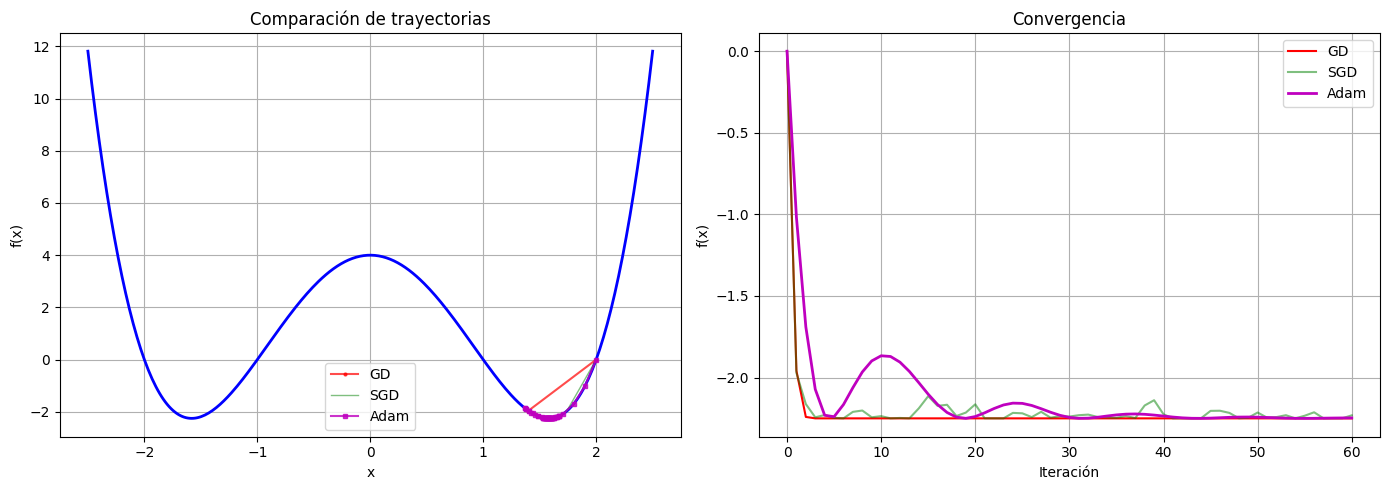

In [9]:
def f(x): return x**4 - 5*x**2 + 4
def df(x): return 4*x**3 - 10*x

def adam_path(df, x0, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8, n_iter=60):
    path = [x0]
    x = x0
    m, v = 0.0, 0.0
    for t in range(1, n_iter + 1):
        g = df(x)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        x = x - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(x)
    return np.array(path)

# Comparar GD vs SGD vs Adam
gd_p = [2.0]
x = 2.0
for _ in range(60):
    x = x - 0.05 * df(x)
    gd_p.append(x)
gd_p = np.array(gd_p)

sgd_p = sgd_path(df, 2.0, 0.02, 60, noise_std=2.0)
adam_p = adam_path(df, 2.0, lr=0.1, n_iter=60)

x_range = np.linspace(-2.5, 2.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_range, f(x_range), 'b-', linewidth=2)
axes[0].plot(gd_p, f(gd_p), 'r-o', markersize=2, label='GD', alpha=0.7)
axes[0].plot(sgd_p, f(sgd_p), 'g-', linewidth=1, label='SGD', alpha=0.5)
axes[0].plot(adam_p, f(adam_p), 'm-s', markersize=3, label='Adam', alpha=0.8)
axes[0].set_title('Comparación de trayectorias')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(f(gd_p), 'r-', label='GD')
axes[1].plot(f(sgd_p), 'g-', alpha=0.5, label='SGD')
axes[1].plot(f(adam_p), 'm-', linewidth=2, label='Adam')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Convergencia')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Animación interactiva

In [10]:
def f(x): return x**4 - 5*x**2 + 4
def df(x): return 4*x**3 - 10*x

adam_p = adam_path(df, 2.0, lr=0.1, n_iter=60)
xs = np.linspace(-2.5, 2.5, 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(xs, f(xs), 'b-', linewidth=2, label='$f(x)$')
point, = ax.plot([], [], 'mo', markersize=10, zorder=5)
trail, = ax.plot([], [], 'm--', linewidth=1, alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Adam Optimizer')
ax.legend()
ax.grid(True)

status = ax.text(0.5, 1.06, '', transform=ax.transAxes,
                 ha='center', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

def update(frame):
    xi = adam_p[frame]
    point.set_data([xi], [f(xi)])
    trail.set_data(adam_p[:frame+1], f(adam_p[:frame+1]))
    status.set_text(f'Iter {frame}: x={xi:.4f}, f(x)={f(xi):.4f}')
    return [point, trail, status]

anim = FuncAnimation(fig, update, frames=len(adam_p), interval=150, repeat=False)
plt.close()
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## Recocido Simulado (*Simulated Annealing*)

### ¿Cómo funciona?

El Recocido Simulado está inspirado en el proceso de **recocido** en metalurgia: calentar un metal y enfriarlo lentamente para que los átomos se acomoden en una estructura de baja energía.

A diferencia del Gradient Descent, **no necesita derivadas** y puede **escapar de mínimos locales** aceptando ocasionalmente soluciones **peores**.

En cada paso:
1. Genera un **vecino** aleatorio $x' = x + \text{perturbación}$.
2. Si $f(x') < f(x)$: acepta (es mejor).
3. Si $f(x') \geq f(x)$: acepta con probabilidad $P = e^{-\frac{\Delta f}{T}}$.

La **temperatura** $T$ comienza alta (acepta muchos movimientos malos) y decrece gradualmente (se vuelve más selectivo).

**Pseudocódigo:**

```
función simulated_annealing(f, x_0, T_0, enfriamiento, iteraciones):
    x = x_0, mejor = x_0, T = T_0
    para t desde 1 hasta iteraciones:
        x' = x + perturbación aleatoria
        \u0394f = f(x') - f(x)
        si \u0394f < 0 o random() < exp(-\u0394f / T):
            x = x'
        si f(x) < f(mejor):
            mejor = x
        T = T \u00d7 enfriamiento
    retornar mejor
```

La clave está en que al inicio (T alta) explora ampliamente, y al final (T baja) refina la solución.

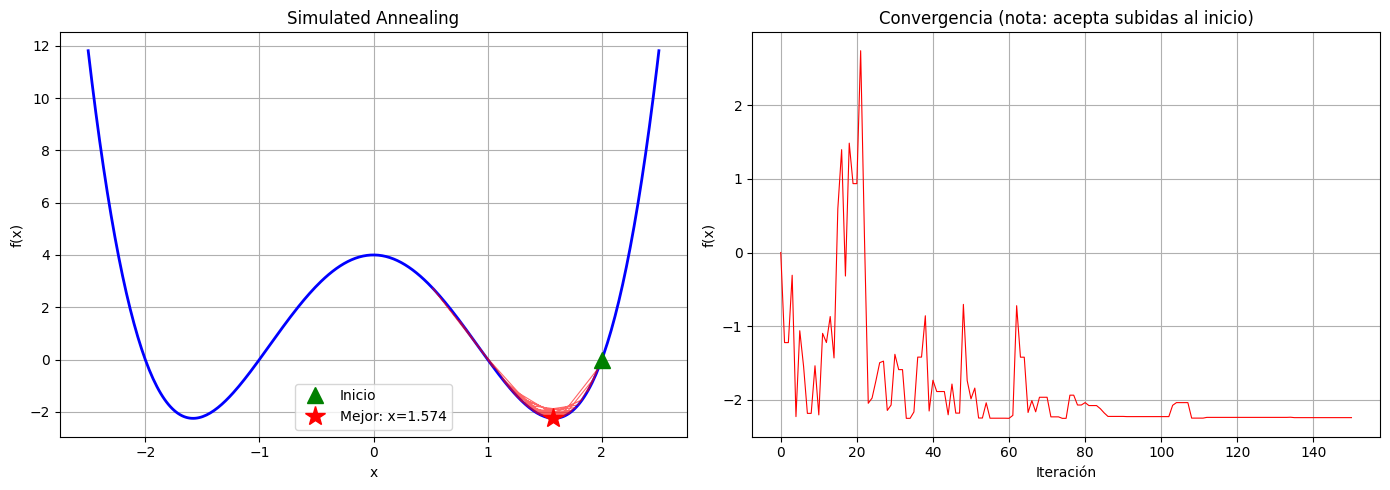

In [11]:
def f(x): return x**4 - 5*x**2 + 4

def simulated_annealing(f, x0, T0=10.0, cooling=0.95, n_iter=100, step_size=0.5, seed=42):
    np.random.seed(seed)
    path = [x0]
    x = x0
    best_x = x0
    T = T0

    for _ in range(n_iter):
        x_new = x + np.random.uniform(-step_size, step_size)
        delta = f(x_new) - f(x)

        if delta < 0 or np.random.random() < np.exp(-delta / max(T, 1e-10)):
            x = x_new

        if f(x) < f(best_x):
            best_x = x

        path.append(x)
        T *= cooling

    return np.array(path), best_x

sa_path, sa_best = simulated_annealing(f, x0=2.0, T0=10.0, cooling=0.95, n_iter=150)
xs = np.linspace(-2.5, 2.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(xs, f(xs), 'b-', linewidth=2)
axes[0].plot(sa_path, f(sa_path), 'r-', linewidth=0.8, alpha=0.6)
axes[0].plot(sa_path[0], f(sa_path[0]), 'g^', markersize=12, label='Inicio')
axes[0].plot(sa_best, f(sa_best), 'r*', markersize=15, label=f'Mejor: x={sa_best:.3f}')
axes[0].set_title('Simulated Annealing')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(f(sa_path), 'r-', linewidth=0.8)
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Convergencia (nota: acepta subidas al inicio)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Animación interactiva

In [12]:
def f(x): return x**4 - 5*x**2 + 4

sa_path, _ = simulated_annealing(f, x0=2.0, T0=10.0, cooling=0.95, n_iter=100)
xs = np.linspace(-2.5, 2.5, 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(xs, f(xs), 'b-', linewidth=2, label='$f(x)$')
point, = ax.plot([], [], 'ro', markersize=8, zorder=5)
trail, = ax.plot([], [], 'r-', linewidth=0.5, alpha=0.4)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Simulated Annealing')
ax.legend()
ax.grid(True)

status = ax.text(0.5, 1.06, '', transform=ax.transAxes,
                 ha='center', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

T_values = [10.0 * 0.95**t for t in range(len(sa_path))]

def update(frame):
    xi = sa_path[frame]
    point.set_data([xi], [f(xi)])
    trail.set_data(sa_path[:frame+1], f(sa_path[:frame+1]))
    T = T_values[frame] if frame < len(T_values) else T_values[-1]
    status.set_text(f'Iter {frame}: x={xi:.3f}, f(x)={f(xi):.3f}, T={T:.3f}')
    return [point, trail, status]

anim = FuncAnimation(fig, update, frames=len(sa_path), interval=100, repeat=False)
plt.close()
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## Optimización por Enjambre de Partículas (*PSO*)

### ¿Cómo funciona?

El PSO está inspirado en el comportamiento de **bandadas de pájaros** o **bancos de peces**. Un grupo de **partículas** explora el espacio, y cada una ajusta su movimiento basándose en:

1. Su **mejor posición personal** ($p_i$): lo mejor que ha encontrado individualmente.
2. La **mejor posición global** ($g$): lo mejor encontrado por cualquier partícula del grupo.

Cada partícula tiene una **posición** $x_i$ y una **velocidad** $v_i$:

$$
v_i^{t+1} = w \cdot v_i^t + c_1 \cdot r_1 \cdot (p_i - x_i^t) + c_2 \cdot r_2 \cdot (g - x_i^t)
$$
$$
x_i^{t+1} = x_i^t + v_i^{t+1}
$$

Donde:
- $w$: **inercia** (qué tanto conserva su velocidad anterior)
- $c_1$: coeficiente **cognitivo** (atracción hacia su mejor posición)
- $c_2$: coeficiente **social** (atracción hacia la mejor global)
- $r_1, r_2$: números aleatorios en $[0, 1]$

Es un algoritmo **poblacional**: múltiples agentes colaboran para encontrar el óptimo.

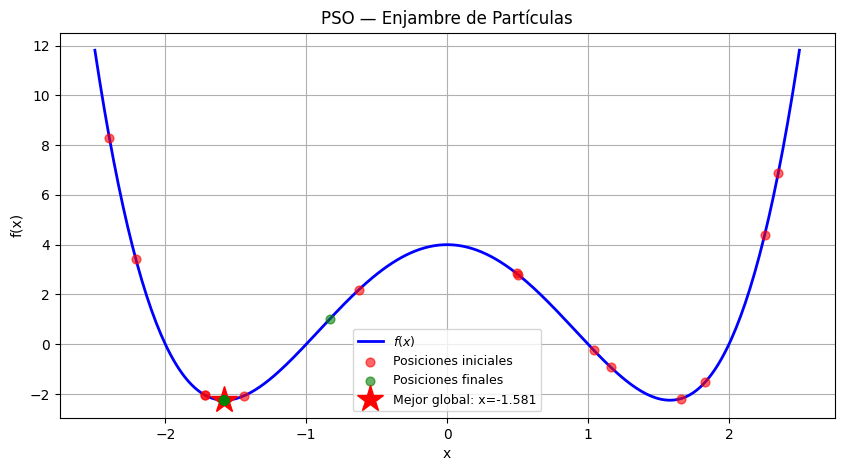

In [13]:
def f(x): return x**4 - 5*x**2 + 4

def pso(f, n_particles=15, n_iter=50, x_range=(-2.5, 2.5),
        w=0.5, c1=1.5, c2=1.5, seed=42):
    np.random.seed(seed)
    # Inicializar posiciones y velocidades
    positions = np.random.uniform(x_range[0], x_range[1], n_particles)
    velocities = np.random.uniform(-0.5, 0.5, n_particles)

    personal_best = positions.copy()
    personal_best_val = np.array([f(x) for x in positions])

    global_best = personal_best[np.argmin(personal_best_val)]
    global_best_val = np.min(personal_best_val)

    history = [positions.copy()]

    for _ in range(n_iter):
        r1 = np.random.random(n_particles)
        r2 = np.random.random(n_particles)

        velocities = (w * velocities
                      + c1 * r1 * (personal_best - positions)
                      + c2 * r2 * (global_best - positions))
        positions = positions + velocities
        positions = np.clip(positions, x_range[0], x_range[1])

        vals = np.array([f(x) for x in positions])

        # Actualizar mejores personales
        improved = vals < personal_best_val
        personal_best[improved] = positions[improved]
        personal_best_val[improved] = vals[improved]

        # Actualizar mejor global
        if np.min(personal_best_val) < global_best_val:
            global_best = personal_best[np.argmin(personal_best_val)]
            global_best_val = np.min(personal_best_val)

        history.append(positions.copy())

    return history, global_best

pso_history, pso_best = pso(f, n_particles=15, n_iter=60)
xs = np.linspace(-2.5, 2.5, 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(xs, f(xs), 'b-', linewidth=2, label='$f(x)$')

# Mostrar estado inicial y final
ax.scatter(pso_history[0], [f(x) for x in pso_history[0]],
           c='red', s=40, alpha=0.6, label='Posiciones iniciales', zorder=5)
ax.scatter(pso_history[-1], [f(x) for x in pso_history[-1]],
           c='green', s=40, alpha=0.6, label='Posiciones finales', zorder=5)
ax.plot(pso_best, f(pso_best), 'r*', markersize=20, label=f'Mejor global: x={pso_best:.3f}')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('PSO — Enjambre de Partículas')
ax.legend(fontsize=9)
ax.grid(True)
plt.show()

### Animación interactiva

La animación muestra las **partículas** (puntos rojos) moviéndose por el espacio y convergiendo hacia el mínimo global.

In [14]:
def f(x): return x**4 - 5*x**2 + 4

pso_history, pso_best = pso(f, n_particles=15, n_iter=60)
xs = np.linspace(-2.5, 2.5, 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(xs, f(xs), 'b-', linewidth=2, label='$f(x)$')
particles = ax.scatter([], [], c='red', s=50, zorder=5, edgecolors='black', label='Partículas')
best_point, = ax.plot([], [], 'r*', markersize=15, zorder=6, label='Mejor global')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('PSO — Enjambre de Partículas')
ax.legend()
ax.grid(True)

status = ax.text(0.5, 1.06, '', transform=ax.transAxes,
                 ha='center', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Track running global best
running_best = [pso_history[0][np.argmin([f(x) for x in pso_history[0]])]]
for h in pso_history[1:]:
    vals = [f(x) for x in h]
    cand = h[np.argmin(vals)]
    if f(cand) < f(running_best[-1]):
        running_best.append(cand)
    else:
        running_best.append(running_best[-1])

def update(frame):
    pos = pso_history[frame]
    ys = [f(x) for x in pos]
    particles.set_offsets(np.column_stack([pos, ys]))

    gb = running_best[frame]
    best_point.set_data([gb], [f(gb)])

    status.set_text(f'Iter {frame}: mejor global x={gb:.3f}, f(x)={f(gb):.3f}')
    return [particles, best_point, status]

anim = FuncAnimation(fig, update, frames=len(pso_history), interval=200, repeat=False)
plt.close()
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## Algoritmo Genético (*Genetic Algorithm*)

### ¿Cómo funciona?

Los algoritmos genéticos está inspirados en la **evolución natural**: una **población** de soluciones evoluciona mediante **selección**, **cruce** y **mutación**.

El ciclo es:

1. **Población inicial**: generar $N$ soluciones aleatorias.
2. **Evaluación (fitness)**: calcular $f(x)$ para cada individuo.
3. **Selección**: elegir los mejores individuos como padres (e.g., torneo, ruleta).
4. **Cruce (crossover)**: combinar dos padres para crear hijos.
5. **Mutación**: perturbar aleatoriamente algunos hijos.
6. Repetir desde el paso 2.

**Pseudocódigo:**

```
función genético(f, N, generaciones, p_mutación):
    población = N soluciones aleatorias
    para cada generación:
        evaluar fitness de cada individuo
        padres = seleccionar los mejores
        hijos = cruzar pares de padres
        mutar hijos con probabilidad p_mutación
        población = hijos
    retornar mejor individuo
```

Es un método **poblacional** que mantiene **diversidad**: múltiples soluciones candidatas evolucionan simultáeamente, lo que ayuda a escapar de m\u00ednimos locales.

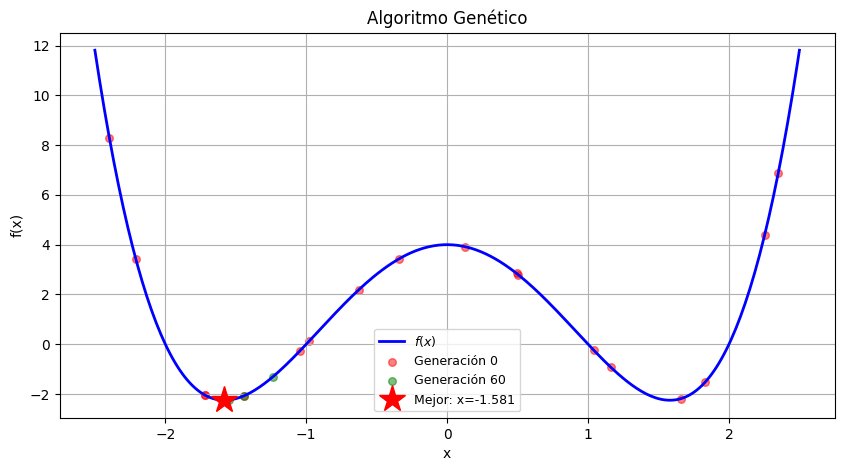

In [15]:
def f(x): return x**4 - 5*x**2 + 4

def genetic_algorithm(f, pop_size=20, n_gen=50, x_range=(-2.5, 2.5),
                      mutation_rate=0.3, mutation_scale=0.3, seed=42):
    np.random.seed(seed)
    pop = np.random.uniform(x_range[0], x_range[1], pop_size)
    history = [pop.copy()]

    for _ in range(n_gen):
        fitness = -np.array([f(x) for x in pop])  # negate because we minimize

        # Selection: tournament selection
        parents = []
        for _ in range(pop_size):
            i, j = np.random.choice(pop_size, 2, replace=False)
            parents.append(pop[i] if fitness[i] > fitness[j] else pop[j])
        parents = np.array(parents)

        # Crossover: arithmetic crossover
        children = []
        for k in range(0, pop_size, 2):
            p1, p2 = parents[k % pop_size], parents[(k + 1) % pop_size]
            alpha = np.random.random()
            c1 = alpha * p1 + (1 - alpha) * p2
            c2 = (1 - alpha) * p1 + alpha * p2
            children.extend([c1, c2])
        children = np.array(children[:pop_size])

        # Mutation
        mask = np.random.random(pop_size) < mutation_rate
        children[mask] += np.random.normal(0, mutation_scale, mask.sum())
        children = np.clip(children, x_range[0], x_range[1])

        # Elitism: keep best from previous generation
        best_idx = np.argmax(fitness)
        worst_child_idx = np.argmin([-f(x) for x in children])
        children[worst_child_idx] = pop[best_idx]

        pop = children
        history.append(pop.copy())

    best = pop[np.argmin([f(x) for x in pop])]
    return history, best

ga_history, ga_best = genetic_algorithm(f, pop_size=20, n_gen=60)
xs = np.linspace(-2.5, 2.5, 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(xs, f(xs), 'b-', linewidth=2, label='$f(x)$')
ax.scatter(ga_history[0], [f(x) for x in ga_history[0]],
           c='red', s=30, alpha=0.5, label='Generación 0')
ax.scatter(ga_history[-1], [f(x) for x in ga_history[-1]],
           c='green', s=30, alpha=0.5, label=f'Generación {len(ga_history)-1}')
ax.plot(ga_best, f(ga_best), 'r*', markersize=20, label=f'Mejor: x={ga_best:.3f}')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Algoritmo Genético')
ax.legend(fontsize=9)
ax.grid(True)
plt.show()

### Animación interactiva

La animación muestra cómo la **población** (puntos) evoluciona generación a generación, convergiendo hacia los mínimos.

In [16]:
def f(x): return x**4 - 5*x**2 + 4

ga_history, ga_best = genetic_algorithm(f, pop_size=20, n_gen=60)
xs = np.linspace(-2.5, 2.5, 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(xs, f(xs), 'b-', linewidth=2, label='$f(x)$')
particles = ax.scatter([], [], c='red', s=40, zorder=5, edgecolors='black', label='Población')
best_point, = ax.plot([], [], 'r*', markersize=15, zorder=6, label='Mejor')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Algoritmo Genético — Evolución')
ax.legend()
ax.grid(True)

status = ax.text(0.5, 1.06, '', transform=ax.transAxes,
                 ha='center', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

running_best_ga = []
for h in ga_history:
    vals = [f(x) for x in h]
    idx = np.argmin(vals)
    if not running_best_ga or vals[idx] < f(running_best_ga[-1]):
        running_best_ga.append(h[idx])
    else:
        running_best_ga.append(running_best_ga[-1])

def update(frame):
    pop = ga_history[frame]
    ys = [f(x) for x in pop]
    particles.set_offsets(np.column_stack([pop, ys]))
    gb = running_best_ga[frame]
    best_point.set_data([gb], [f(gb)])
    status.set_text(f'Gen {frame}: mejor x={gb:.3f}, f(x)={f(gb):.3f}')
    return [particles, best_point, status]

anim = FuncAnimation(fig, update, frames=len(ga_history), interval=200, repeat=False)
plt.close()
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## Comparación de Algoritmos

| Algoritmo | Tipo | Usa gradiente | Convergencia | Escapa mín. locales |
|---|---|---|---|---|
| **Gradient Descent** | Determinístico | Sí | $O(1/t)$ | No |
| **Newton** | Determinístico | Sí ($f'$, $f''$) | Cuadrática | No |
| **SGD** | Estocástico | Sí (ruidoso) | $O(1/\sqrt{t})$ | Parcialmente |
| **Adam** | Adaptativo | Sí | Rápida en práctica | Parcialmente |
| **Simulated Annealing** | Metaheurístico | No | Probabilística | **Sí** |
| **PSO** | Poblacional | No | Probabilística | **Sí** |
| **Genético** | Poblacional | No | Probabilística | **Sí** |

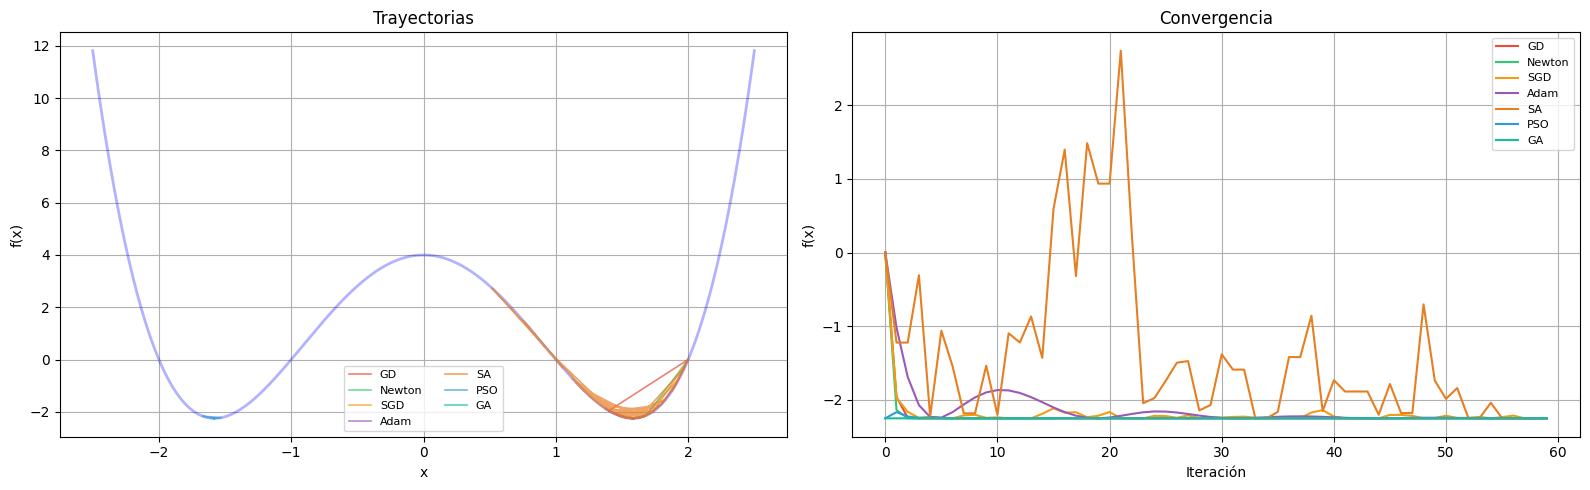

In [17]:
def f(x): return x**4 - 5*x**2 + 4
def df(x): return 4*x**3 - 10*x
def ddf(x): return 12*x**2 - 10

# Ejecutar todos los algoritmos
results = {}

# GD
x = 2.0
p = [x]
for _ in range(80):
    x = x - 0.05 * df(x)
    p.append(x)
results['GD'] = np.array(p)

# Newton
results['Newton'] = newton_path(f, df, ddf, 2.0, 15)

# SGD
results['SGD'] = sgd_path(df, 2.0, 0.02, 80, noise_std=2.0)

# Adam
results['Adam'] = adam_path(df, 2.0, lr=0.1, n_iter=80)

# SA
sa_p, _ = simulated_annealing(f, 2.0, T0=10.0, cooling=0.95, n_iter=80)
results['SA'] = sa_p

# PSO (best per iteration)
pso_h, _ = pso(f, n_particles=15, n_iter=80)
pso_bests = []
for h in pso_h:
    pso_bests.append(min(h, key=f))
results['PSO'] = np.array(pso_bests)

# GA (best per generation)
ga_h, _ = genetic_algorithm(f, pop_size=20, n_gen=80)
ga_bests = []
for h in ga_h:
    ga_bests.append(min(h, key=f))
results['GA'] = np.array(ga_bests)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = {'GD': '#E74C3C', 'Newton': '#2ECC71', 'SGD': '#F39C12',
          'Adam': '#9B59B6', 'SA': '#E67E22', 'PSO': '#3498DB', 'GA': '#1ABC9C'}

# Trayectorias
xs = np.linspace(-2.5, 2.5, 300)
axes[0].plot(xs, f(xs), 'b-', linewidth=2, alpha=0.3)
for name, path in results.items():
    axes[0].plot(path, f(path), '-', color=colors[name], linewidth=1.2,
                 alpha=0.7, label=name)
axes[0].set_title('Trayectorias')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(True)

# Convergencia
for name, path in results.items():
    vals = [f(x) for x in path]
    axes[1].plot(vals[:60], '-', color=colors[name], linewidth=1.5, label=name)
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Convergencia')
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Implementación con Código

### Funciones

In [18]:
import numpy as np

def gradient_descent(f, df, x0, lr=0.01, n_iter=100):
    """Gradient Descent básico."""
    x = x0
    for _ in range(n_iter):
        x = x - lr * df(x)
    return x

def newton_method(f, df, ddf, x0, n_iter=20):
    """Método de Newton."""
    x = x0
    for _ in range(n_iter):
        d2 = ddf(x)
        if abs(d2) < 1e-10: break
        x = x - df(x) / d2
    return x

def sgd(f, df, x0, lr=0.01, n_iter=100, noise_std=1.0):
    """SGD simulado con ruido gaussiano."""
    x = x0
    for _ in range(n_iter):
        g = df(x) + np.random.normal(0, noise_std)
        x = x - lr * g
    return x

def adam(f, df, x0, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, n_iter=100):
    """Adam optimizer."""
    x = x0
    m, v = 0.0, 0.0
    for t in range(1, n_iter + 1):
        g = df(x)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        x = x - lr * m_hat / (np.sqrt(v_hat) + eps)
    return x

def sim_annealing(f, x0, T0=10.0, cooling=0.95, n_iter=200, step_size=0.5):
    """Simulated Annealing."""
    x = x0; best = x0; T = T0
    for _ in range(n_iter):
        x_new = x + np.random.uniform(-step_size, step_size)
        delta = f(x_new) - f(x)
        if delta < 0 or np.random.random() < np.exp(-delta / max(T, 1e-10)):
            x = x_new
        if f(x) < f(best): best = x
        T *= cooling
    return best

def particle_swarm(f, n_particles=20, n_iter=100, x_range=(-2.5, 2.5), w=0.5, c1=1.5, c2=1.5):
    """Particle Swarm Optimization."""
    pos = np.random.uniform(x_range[0], x_range[1], n_particles)
    vel = np.random.uniform(-0.5, 0.5, n_particles)
    pbest = pos.copy(); pbest_val = np.array([f(x) for x in pos])
    gbest = pbest[np.argmin(pbest_val)]
    for _ in range(n_iter):
        r1, r2 = np.random.random(n_particles), np.random.random(n_particles)
        vel = w * vel + c1 * r1 * (pbest - pos) + c2 * r2 * (gbest - pos)
        pos = np.clip(pos + vel, x_range[0], x_range[1])
        vals = np.array([f(x) for x in pos])
        improved = vals < pbest_val
        pbest[improved] = pos[improved]; pbest_val[improved] = vals[improved]
        if np.min(pbest_val) < f(gbest): gbest = pbest[np.argmin(pbest_val)]
    return gbest

def genetic_algo(f, pop_size=30, n_gen=100, x_range=(-2.5, 2.5), mut_rate=0.3, mut_scale=0.3):
    """Algoritmo Genético."""
    pop = np.random.uniform(x_range[0], x_range[1], pop_size)
    for _ in range(n_gen):
        fitness = -np.array([f(x) for x in pop])
        parents = []
        for _ in range(pop_size):
            i, j = np.random.choice(pop_size, 2, replace=False)
            parents.append(pop[i] if fitness[i] > fitness[j] else pop[j])
        parents = np.array(parents)
        children = []
        for k in range(0, pop_size, 2):
            a = np.random.random()
            children.extend([a*parents[k%pop_size]+(1-a)*parents[(k+1)%pop_size],
                            (1-a)*parents[k%pop_size]+a*parents[(k+1)%pop_size]])
        children = np.array(children[:pop_size])
        mask = np.random.random(pop_size) < mut_rate
        children[mask] += np.random.normal(0, mut_scale, mask.sum())
        children = np.clip(children, x_range[0], x_range[1])
        best_idx = np.argmax(fitness)
        children[np.argmin([-f(x) for x in children])] = pop[best_idx]
        pop = children
    return pop[np.argmin([f(x) for x in pop])]

In [19]:
def f(x): return x**4 - 5*x**2 + 4
def df(x): return 4*x**3 - 10*x
def ddf(x): return 12*x**2 - 10

np.random.seed(42)
print(f"Mínimos teóricos: x = ±{np.sqrt(2.5):.4f}, f(x) = {f(np.sqrt(2.5)):.4f}")
print(f"{'='*55}")
print(f"{'Algoritmo':20s} {'x*':>10s} {'f(x*)':>10s}")
print(f"{'-'*55}")
print(f"{'Gradient Descent':20s} {gradient_descent(f, df, 2.0, lr=0.05, n_iter=100):10.4f} {f(gradient_descent(f, df, 2.0, lr=0.05, n_iter=100)):10.4f}")
print(f"{'Newton':20s} {newton_method(f, df, ddf, 2.0):10.4f} {f(newton_method(f, df, ddf, 2.0)):10.4f}")
print(f"{'SGD':20s} {sgd(f, df, 2.0, lr=0.02, n_iter=200):10.4f} {f(sgd(f, df, 2.0, lr=0.02, n_iter=200)):10.4f}")
print(f"{'Adam':20s} {adam(f, df, 2.0, lr=0.1, n_iter=100):10.4f} {f(adam(f, df, 2.0, lr=0.1, n_iter=100)):10.4f}")
print(f"{'Sim. Annealing':20s} {sim_annealing(f, 2.0):10.4f} {f(sim_annealing(f, 2.0)):10.4f}")
print(f"{'PSO':20s} {particle_swarm(f):10.4f} {f(particle_swarm(f)):10.4f}")
print(f"{'Genético':20s} {genetic_algo(f):10.4f} {f(genetic_algo(f)):10.4f}")

Mínimos teóricos: x = ±1.5811, f(x) = -2.2500
Algoritmo                    x*      f(x*)
-------------------------------------------------------
Gradient Descent         1.5811    -2.2500
Newton                   1.5811    -2.2500
SGD                      1.6057    -2.2425
Adam                     1.5790    -2.2500
Sim. Annealing           1.5835    -2.2500
PSO                     -1.5811    -2.2500
Genético                 1.5811    -2.2500
